<a href="https://colab.research.google.com/github/eshikajindal24/UCS547_Accelerated_data_science/blob/main/UCS547_102303954_Assign6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install cuml-cu12 cudf-cu12 cupy-cuda12x

In [2]:
!pip install numba

In [3]:
import cuml
print(cuml.__version__)

26.02.000


**ASSIGNMENT 6**

Ques 1  Using the Adult Census Income Dataset (UCI Machine Learning Repository), design and
implement a complete machine learning pipeline to analyze and demonstrate GPU-accelerated
binning and model training.
• Load and Preprocess the Dataset
• Identify Feature Types
o Classify features as Continuous, Discrete, Categorical, or Binary.
o Indicate which features are eligible for histogram binning on the GPU.
• Demonstrate GPU-Based Histogram Binning
o Use cuDF and CuPy to compute histograms for continuous features.
o Compare results with CPU-based NumPy histograms and visualize them.
• Perform Quantile Binning on the GPU
o Compute quantiles and assign bin labels using GPU libraries.
o Display bin edges and illustrate balanced data distribution.
• Train and Compare CPU and GPU Models Performance
• Implement the same experiment using XGBoost with tree_method='gpu_hist' and
compare the results with cuML.

In [16]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# CPU
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score as sk_accuracy
from sklearn.tree import DecisionTreeClassifier

# GPU
import cudf
import cupy as cp
from cuml.ensemble import RandomForestClassifier
from cuml.metrics import accuracy_score as cu_accuracy

In [17]:
print("Loading dataset")

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race",
    "sex", "capital-gain", "capital-loss", "hours-per-week",
    "native-country", "income"
]

df = pd.read_csv(url, names=columns, na_values=" ?", skipinitialspace=True)
print(df.head())

Loading dataset
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0           

In [18]:
print("Data Preprocessing")

df = df.dropna()

label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print(df.head())

Data Preprocessing
   age  workclass  fnlwgt  education  education-num  marital-status  \
0   39          7   77516          9             13               4   
1   50          6   83311          9             13               2   
2   38          4  215646         11              9               0   
3   53          4  234721          1              7               2   
4   28          4  338409          9             13               2   

   occupation  relationship  race  sex  capital-gain  capital-loss  \
0           1             1     4    1          2174             0   
1           4             0     4    1             0             0   
2           6             1     4    1             0             0   
3           6             0     2    1             0             0   
4          10             5     2    0             0             0   

   hours-per-week  native-country  income  
0              40              39       0  
1              13              39       0  
2

In [19]:
print("\n===== FEATURE TYPE IDENTIFICATION =====")

feature_types = {}
binning_eligible = []

for col in df.columns:
    unique_vals = df[col].nunique()

    if unique_vals == 2:
        feature_types[col] = "Binary"
        eligible = "No"

    elif unique_vals < 20:
        feature_types[col] = "Categorical/Discrete"
        eligible = "No"

    else:
        feature_types[col] = "Continuous"
        eligible = "Yes"
        binning_eligible.append(col)

    print(f"{col}: {feature_types[col]} | Histogram Binning Eligible: {eligible}")

print("\nEligible Features for GPU Histogram Binning:")
print(binning_eligible)


===== FEATURE TYPE IDENTIFICATION =====
age: Continuous | Histogram Binning Eligible: Yes
workclass: Categorical/Discrete | Histogram Binning Eligible: No
fnlwgt: Continuous | Histogram Binning Eligible: Yes
education: Categorical/Discrete | Histogram Binning Eligible: No
education-num: Categorical/Discrete | Histogram Binning Eligible: No
marital-status: Categorical/Discrete | Histogram Binning Eligible: No
occupation: Categorical/Discrete | Histogram Binning Eligible: No
relationship: Categorical/Discrete | Histogram Binning Eligible: No
race: Categorical/Discrete | Histogram Binning Eligible: No
sex: Binary | Histogram Binning Eligible: No
capital-gain: Continuous | Histogram Binning Eligible: Yes
capital-loss: Continuous | Histogram Binning Eligible: Yes
hours-per-week: Continuous | Histogram Binning Eligible: Yes
native-country: Continuous | Histogram Binning Eligible: Yes
income: Binary | Histogram Binning Eligible: No

Eligible Features for GPU Histogram Binning:
['age', 'fnlwg

In [20]:
X = df.drop("income", axis=1)
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_cu = cudf.DataFrame(X_train)
X_test_cu = cudf.DataFrame(X_test)
y_train_cu = cudf.Series(y_train.values)
y_test_cu = cudf.Series(y_test.values)


===== HISTOGRAM BINNING ON GPU =====

Using Feature: age
    Bin Start  Bin End  CPU Count  GPU Count
0     17.0000  21.5625       2493       2493
1     21.5625  26.1250       3242       3242
2     26.1250  30.6875       2743       2743
3     30.6875  35.2500       3463       3463
4     35.2500  39.8125       2726       2726
5     39.8125  44.3750       3136       3136
6     44.3750  48.9375       2164       2164
7     48.9375  53.5000       2143       2143
8     53.5000  58.0625       1518       1518
9     58.0625  62.6250        991        991
10    62.6250  67.1875        737        737
11    67.1875  71.7500        315        315
12    71.7500  76.3125        223        223
13    76.3125  80.8750         78         78
14    80.8750  85.4375         37         37
15    85.4375  90.0000         39         39


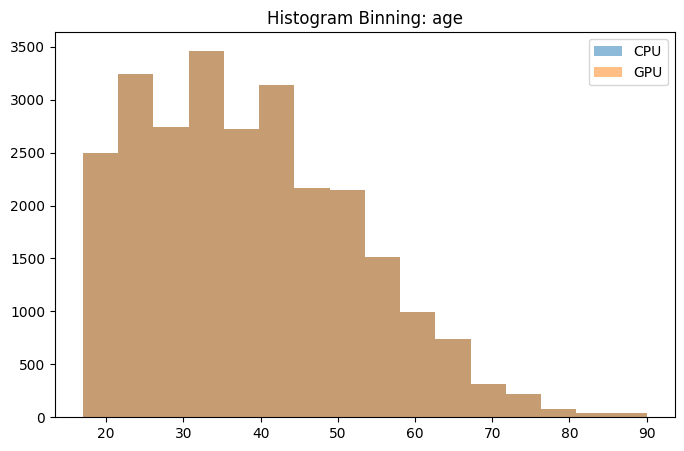

In [21]:
print("Histogram binning on GPU")

feature_name = binning_eligible[0]

cpu_feature = X_train[feature_name].values
gpu_feature = X_train_cu[feature_name].to_cupy()

num_bins = 16

gpu_hist, bin_edges = cp.histogram(gpu_feature, bins=num_bins)
cpu_hist, _ = np.histogram(cpu_feature, bins=cp.asnumpy(bin_edges))

gpu_hist_np = cp.asnumpy(gpu_hist)
bin_edges_np = cp.asnumpy(bin_edges)

bin_df = pd.DataFrame({
    "Bin Start": bin_edges_np[:-1],
    "Bin End": bin_edges_np[1:],
    "CPU Count": cpu_hist,
    "GPU Count": gpu_hist_np
})

print(f"\nUsing Feature: {feature_name}")
print(bin_df)

plt.figure(figsize=(8,5))
plt.hist(cpu_feature, bins=num_bins, alpha=0.5, label="CPU")
plt.hist(cp.asnumpy(gpu_feature), bins=num_bins, alpha=0.5, label="GPU")
plt.title(f"Histogram Binning: {feature_name}")
plt.legend()
plt.show()


===== QUANTILE BINNING ON GPU =====

Quantile Bin Edges:
[17. 28. 37. 48. 90.]

Balanced Distribution Across Bins:
   Bin  CPU Count  GPU Count
0    0       6405       6405
1    1       6245       6245
2    2       6882       6882
3    3       6516       6516


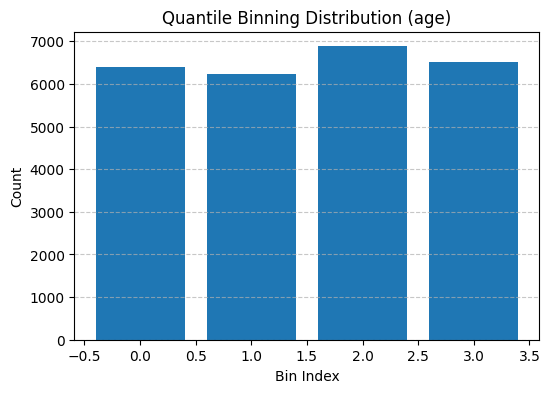

In [22]:
print("\n===== QUANTILE BINNING ON GPU =====")

feature_name = binning_eligible[0]

cpu_feature = X_train[feature_name].values
gpu_feature = X_train_cu[feature_name].to_cupy()

num_bins = 4
quantiles = cp.linspace(0, 100, num_bins + 1)

bin_edges_gpu = cp.percentile(gpu_feature, quantiles)
cp.cuda.Stream.null.synchronize()

bin_edges = cp.asnumpy(bin_edges_gpu)
bin_edges = np.unique(bin_edges)

print("\nQuantile Bin Edges:")
print(bin_edges)

gpu_bin_labels = cp.digitize(gpu_feature, bin_edges_gpu[1:-1])
cpu_bin_labels = np.digitize(cpu_feature, bin_edges[1:-1])

gpu_labels_np = cp.asnumpy(gpu_bin_labels)

gpu_counts = np.bincount(gpu_labels_np)
cpu_counts = np.bincount(cpu_bin_labels)

bin_df = pd.DataFrame({
    "Bin": range(len(gpu_counts)),
    "CPU Count": cpu_counts,
    "GPU Count": gpu_counts
})

print("\nBalanced Distribution Across Bins:")
print(bin_df)

plt.figure(figsize=(6,4))
plt.bar(bin_df["Bin"], bin_df["GPU Count"])
plt.title(f"Quantile Binning Distribution ({feature_name})")
plt.xlabel("Bin Index")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [23]:
#Training CPU mODEL

start_cpu = time.time()

cpu_model = DecisionTreeClassifier(max_depth=10)
cpu_model.fit(X_train, y_train)

cpu_pred = cpu_model.predict(X_test)

cpu_time = time.time() - start_cpu
cpu_acc = sk_accuracy(y_test, cpu_pred)

print("CPU Accuracy:", cpu_acc)

CPU Accuracy: 0.8558268079226163


In [24]:
#Training GPU Model

cp.cuda.Stream.null.synchronize()
start_gpu = time.time()

gpu_model = RandomForestClassifier(
    n_estimators=1,
    max_depth=10,
    random_state=42
)

gpu_model.fit(X_train_cu, y_train_cu)
gpu_pred = gpu_model.predict(X_test_cu)

cp.cuda.Stream.null.synchronize()
gpu_time = time.time() - start_gpu
gpu_acc = float(cu_accuracy(y_test_cu, gpu_pred))

print("GPU Accuracy:", gpu_acc)

GPU Accuracy: 0.8367879625364655



===== PERFORMANCE COMPARISON =====
           Metric  CPU (Decision Tree)  GPU (cuML RF)
0        Accuracy             0.855827       0.836788
1  Execution Time             0.090833       0.018321

GPU Speedup: 4.96x


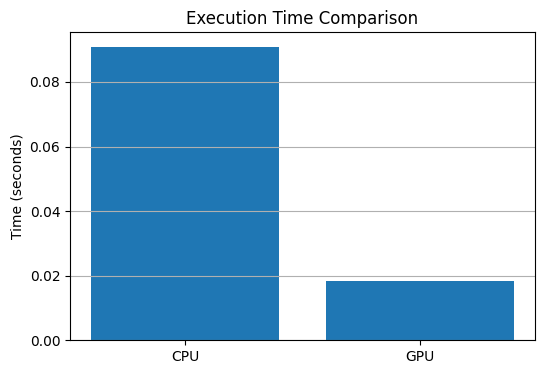

In [25]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Execution Time"],
    "CPU (Decision Tree)": [cpu_acc, cpu_time],
    "GPU (cuML RF)": [gpu_acc, gpu_time]
})

speedup = cpu_time / gpu_time

print("\n===== PERFORMANCE COMPARISON =====")
print(results)
print(f"\nGPU Speedup: {speedup:.2f}x")

plt.figure(figsize=(6,4))
plt.bar(["CPU", "GPU"], [cpu_time, gpu_time])
plt.title("Execution Time Comparison")
plt.ylabel("Time (seconds)")
plt.grid(axis='y')
plt.show()

In [14]:
!pip install xgboost==2.0.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 1.7 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.2.0
    Uninstalling xgboost-3.2.0:
      Successfully uninstalled xgboost-3.2.0



===== XGBOOST (GPU) vs cuML COMPARISON =====


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:160: UserWarning: [04:10:41] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


XGBoost Accuracy: 0.8744050360816827
cuML Accuracy: 0.8576692768309535

===== FINAL COMPARISON =====
                 Metric  XGBoost (GPU)  cuML (GPU)
0              Accuracy       0.874405    0.857669
1  Execution Time (sec)       0.564792    0.228494


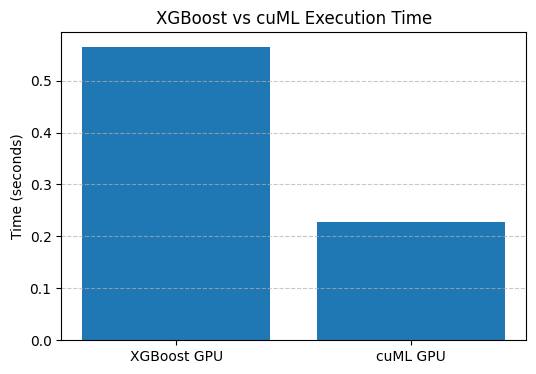

In [26]:

print("\n===== XGBOOST (GPU) vs cuML COMPARISON =====")

from xgboost import XGBClassifier

cp.cuda.Stream.null.synchronize()
start_xgb = time.time()

xgb_model = XGBClassifier(
    tree_method='gpu_hist',
    max_depth=10,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

X_train_np = X_train.values
X_test_np = X_test.values
y_train_np = y_train.values
y_test_np = y_test.values

xgb_model.fit(X_train_np, y_train_np)
xgb_pred = xgb_model.predict(X_test_np)

cp.cuda.Stream.null.synchronize()
xgb_time = time.time() - start_xgb
xgb_acc = sk_accuracy(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_acc)


cp.cuda.Stream.null.synchronize()
start_cuml = time.time()

cuml_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

cuml_model.fit(X_train_cu, y_train_cu)
cuml_pred = cuml_model.predict(X_test_cu)

cp.cuda.Stream.null.synchronize()
cuml_time = time.time() - start_cuml
cuml_acc = float(cu_accuracy(y_test_cu, cuml_pred))

print("cuML Accuracy:", cuml_acc)

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Execution Time (sec)"],
    "XGBoost (GPU)": [xgb_acc, xgb_time],
    "cuML (GPU)": [cuml_acc, cuml_time]
})

print("\n===== FINAL COMPARISON =====")
print(comparison_df)

plt.figure(figsize=(6,4))
plt.bar(["XGBoost GPU", "cuML GPU"], [xgb_time, cuml_time])
plt.title("XGBoost vs cuML Execution Time")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Ques 2  Implement a Random Forest classifier using both scikit-learn (CPU) and RAPIDS cuML
(GPU) on the UCI Breast Cancer Dataset. Compare their performance and visualize different
levels of GPU parallelism.
1. Data Preparation
o Load the dataset using load_breast_cancer().
o Split it into training and testing sets.
o Convert the dataset into cuDF format for GPU processing.
2. CPU Implementation
o Train a Random Forest model using scikit-learn.
o Record training time, prediction time, and accuracy.
3. GPU Implementation
o Train a Random Forest model using RAPIDS cuML.
o Measure training time, prediction time, and accuracy.
o Compute GPU speedup over the CPU.
4. Visualization of Parallelism
o Forest-Level Parallelism: Plot training time vs. number of trees (n_estimators = 1,
10, 50, 100).
o Feature-Level Parallelism: Plot feature importance from the trained model.
o Data-Level Parallelism: Measure training time for varying dataset sizes.
o Bin-Level Parallelism: Demonstrate GPU histogram binning using CuPy.
5. Performance Comparison
o Create a table comparing CPU and GPU results.
o Visualize execution time using bar charts.

In [42]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# CPU
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier as skRF
from sklearn.metrics import accuracy_score as sk_accuracy

# GPU
import cudf
import cupy as cp
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.metrics import accuracy_score as cu_accuracy

In [43]:
print("Dataset Preparation")

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_cu = cudf.DataFrame(X_train)
X_test_cu = cudf.DataFrame(X_test)
y_train_cu = cudf.Series(y_train)
y_test_cu = cudf.Series(y_test)

print("Dataset shape:", X.shape)

Dataset Preparation
Dataset shape: (569, 30)


In [44]:
print("\n===== CPU RANDOM FOREST =====")

# Training Time
start_train_cpu = time.time()

cpu_model = skRF(n_estimators=100, max_depth=10, random_state=42)
cpu_model.fit(X_train, y_train)

train_time_cpu = time.time() - start_train_cpu

# Prediction Time
start_pred_cpu = time.time()

cpu_pred = cpu_model.predict(X_test)

pred_time_cpu = time.time() - start_pred_cpu

# Accuracy
cpu_acc = sk_accuracy(y_test, cpu_pred)

print("CPU Training Time:", train_time_cpu)
print("CPU Prediction Time:", pred_time_cpu)
print("CPU Accuracy:", cpu_acc)


===== CPU RANDOM FOREST =====
CPU Training Time: 0.2462458610534668
CPU Prediction Time: 0.0061070919036865234
CPU Accuracy: 0.9649122807017544


In [57]:
print("\n===== GPU RANDOM FOREST =====")

# Warm-up run (NOT timed)
warm_model = cuRF(n_estimators=10, max_depth=5)
warm_model.fit(X_train_cu, y_train_cu)
cp.cuda.Stream.null.synchronize()

# Training Time
cp.cuda.Stream.null.synchronize()
start_train_gpu = time.time()

gpu_model = cuRF(n_estimators=100, max_depth=10, random_state=42)
gpu_model.fit(X_train_cu, y_train_cu)

cp.cuda.Stream.null.synchronize()
train_time_gpu = time.time() - start_train_gpu

# Prediction Time
cp.cuda.Stream.null.synchronize()
start_pred_gpu = time.time()

gpu_pred = gpu_model.predict(X_test_cu)

cp.cuda.Stream.null.synchronize()
pred_time_gpu = time.time() - start_pred_gpu

# Accuracy
gpu_acc = float(cu_accuracy(y_test_cu, gpu_pred))

print("GPU Training Time:", train_time_gpu)
print("GPU Prediction Time:", pred_time_gpu)
print("GPU Accuracy:", gpu_acc)


===== GPU RANDOM FOREST =====
GPU Training Time: 0.24120092391967773
GPU Prediction Time: 0.003734588623046875
GPU Accuracy: 0.9649122807017544



===== PERFORMANCE COMPARISON =====
            Metric       CPU       GPU
0         Accuracy  0.964912  0.964912
1    Training Time  0.246246  0.241201
2  Prediction Time  0.006107  0.003735


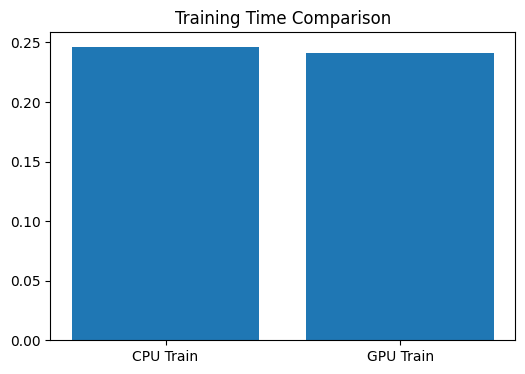

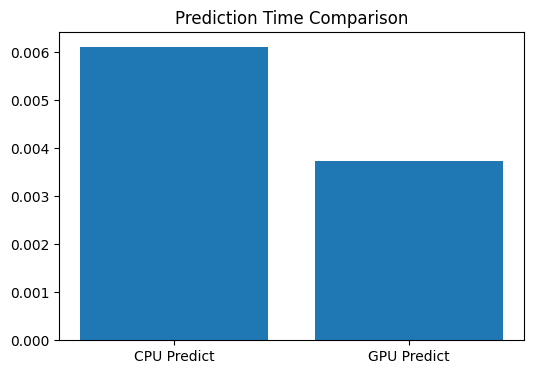

In [58]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Training Time", "Prediction Time"],
    "CPU": [cpu_acc, train_time_cpu, pred_time_cpu],
    "GPU": [gpu_acc, train_time_gpu, pred_time_gpu]
})

print("\n===== PERFORMANCE COMPARISON =====")
print(results)

plt.figure(figsize=(6,4))
plt.bar(["CPU Train", "GPU Train"], [train_time_cpu, train_time_gpu])
plt.title("Training Time Comparison")
plt.show()

plt.figure(figsize=(6,4))
plt.bar(["CPU Predict", "GPU Predict"], [pred_time_cpu, pred_time_gpu])
plt.title("Prediction Time Comparison")
plt.show()


===== FOREST-LEVEL PARALLELISM =====


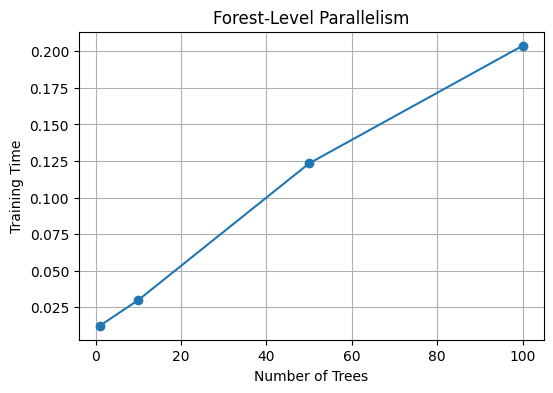

In [47]:
print("\n===== FOREST-LEVEL PARALLELISM =====")

tree_counts = [1, 10, 50, 100]
times = []

for n in tree_counts:
    cp.cuda.Stream.null.synchronize()
    start = time.time()

    model = cuRF(n_estimators=n, max_depth=10)
    model.fit(X_train_cu, y_train_cu)

    cp.cuda.Stream.null.synchronize()
    times.append(time.time() - start)

plt.figure(figsize=(6,4))
plt.plot(tree_counts, times, marker='o')
plt.title("Forest-Level Parallelism")
plt.xlabel("Number of Trees")
plt.ylabel("Training Time")
plt.grid()
plt.show()


===== FEATURE-LEVEL PARALLELISM =====


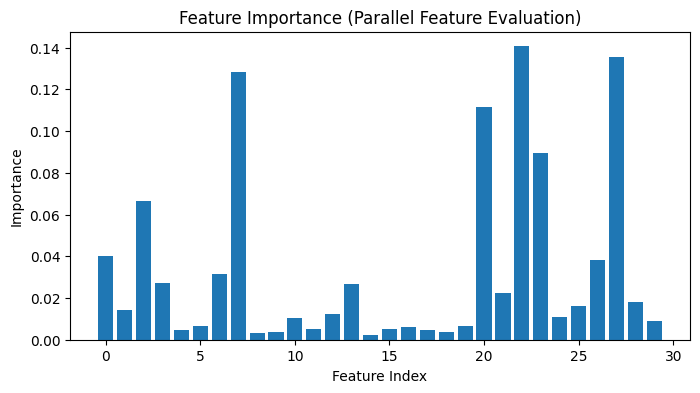

In [48]:
print("\n===== FEATURE-LEVEL PARALLELISM =====")

importances = gpu_model.feature_importances_

plt.figure(figsize=(8,4))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance (Parallel Feature Evaluation)")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()


===== DATA-LEVEL PARALLELISM =====


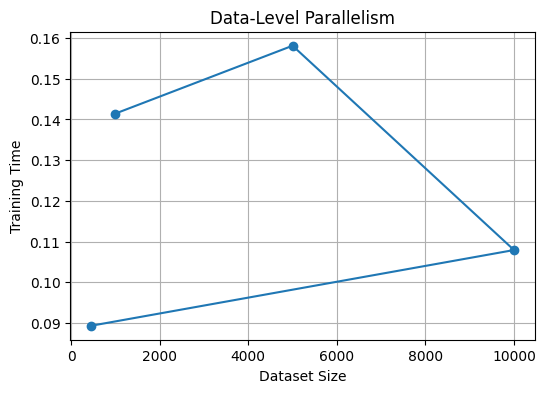

In [49]:
print("\n===== DATA-LEVEL PARALLELISM =====")

sizes = [1000, 5000, 10000, len(X_train)]
times = []

for size in sizes:
    X_sub = X_train_cu.iloc[:size]
    y_sub = y_train_cu.iloc[:size]

    cp.cuda.Stream.null.synchronize()
    start = time.time()

    model = cuRF(n_estimators=50, max_depth=10)
    model.fit(X_sub, y_sub)

    cp.cuda.Stream.null.synchronize()
    times.append(time.time() - start)

plt.figure(figsize=(6,4))
plt.plot(sizes, times, marker='o')
plt.title("Data-Level Parallelism")
plt.xlabel("Dataset Size")
plt.ylabel("Training Time")
plt.grid()
plt.show()

In [50]:
print("\n===== BIN-LEVEL PARALLELISM =====")

feature = X_train_cu.iloc[:, 0].to_cupy()

hist, bins = cp.histogram(feature, bins=16)

print("Histogram Counts:", cp.asnumpy(hist))


===== BIN-LEVEL PARALLELISM =====
Histogram Counts: [14 30 59 85 85 58 26 20 24 29 13  2  5  1  1  3]



===== FINAL RESULTS =====
                 Metric  CPU (sklearn)  GPU (cuML)
0              Accuracy       0.964912    0.964912
1  Total Execution Time       0.252353    0.244936


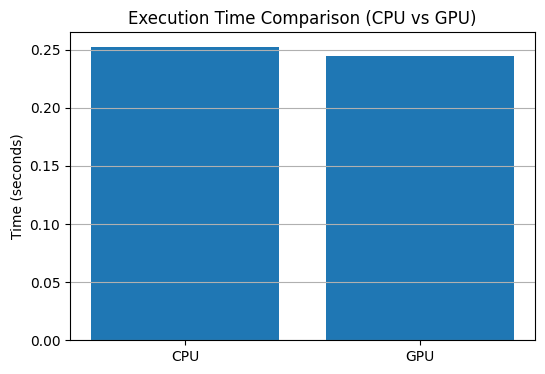

In [59]:
cpu_total_time = train_time_cpu + pred_time_cpu
gpu_total_time = train_time_gpu + pred_time_gpu

final_df = pd.DataFrame({
    "Metric": ["Accuracy", "Total Execution Time"],
    "CPU (sklearn)": [cpu_acc, cpu_total_time],
    "GPU (cuML)": [gpu_acc, gpu_total_time]
})

print("\n===== FINAL RESULTS =====")
print(final_df)

plt.figure(figsize=(6,4))
plt.bar(["CPU", "GPU"], [cpu_total_time, gpu_total_time])
plt.title("Execution Time Comparison (CPU vs GPU)")
plt.ylabel("Time (seconds)")
plt.grid(axis='y')
plt.show()